# Run 2 vs. Run 3 trigger efficiency comparison 

In this notebook I will open data files from both run three and run 2 and see if the resolution has improved as expected. To do so I will compare triggers that are closely related or the same and apply them to data for each run. Then using histograms and efficiency calculations I will see if there are changes in resolution, in particular I expect to see the most significant changes in the lower GeV muon_pt data.

## Open Relevant Libraries and Data Files

In [1]:
# Import all necessary libraries

import uproot
import numpy as np
import awkward as ak
import pandas as pd
import matplotlib.pyplot as plt
import boost_histogram as bh
import hist
import vector

from typing import List, Any, Dict, Optional

# We also want to import things from sidm that are not libraries pre-installed to coffea
import sys
# Tell Python to look one directory up (which should be the root of the 'sidm' project)
sys.path.append("/home/cms-jovyan/SIDM/SIDM/") 

# Now the import should work because 'sidm' is in the path
from sidm.tools import utilities

import mplhep as hep
plt.style.use(hep.style.CMS)

In [2]:
# Run 3 file path 

R3file_path = "root://xcache//store/user/lpcmetx/SIDM/ULSignalSamples/2024/nanoaodYear2024.root"
R3file = uproot.open(R3file_path)

In [3]:
# Run 2 500GeV file path 

R2file_path = "root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo4Mu/CutDecayFalse_SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p8_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo4Mu_MBs-500_MDp-5p0_ctau-0p8_v3_part-22.root"
R2file = uproot.open(R2file_path)

In [4]:
# Run 2 100GeV file path

R2100file_path = "root://xcache//store/group/lpcmetx/SIDM/ULSignalSamples/2018_v10/BsTo2DpTo4Mu/CutDecayFalse_SIDM_BsTo2DpTo4Mu_MBs-100_MDp-5p0_ctau-4p0_v3/LLPnanoAODv2/CutDecayFalse_SIDM_BsTo2DpTo4Mu_MBs-100_MDp-5p0_ctau-4p0_v3_part-0.root"
R2100file = uproot.open(R2100file_path)

In [5]:
# Examine contents of each file

R3file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [6]:
R2file.keys()

['tag;1',
 'Events;1',
 'LuminosityBlocks;1',
 'Runs;1',
 'MetaData;1',
 'ParameterSets;1']

In [7]:
# The data we want will be contained in the Events TTree so we'll open that one
R3Events = R3file["Events"]
R3Events.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
bunchCrossing        | uint32_t                 | AsDtype('>u4')
orbitNumber          | uint32_t                 | AsDtype('>u4')
HTXS_njets25         | uint8_t                  | AsDtype('uint8')
HTXS_njets30         | uint8_t                  | AsDtype('uint8')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDt

In [8]:
# The data we want will be contained in the Events TTree so we'll open that one
R2Events = R2file["Events"]
R2Events.show()

name                 | typename                 | interpretation                
---------------------+--------------------------+-------------------------------
run                  | uint32_t                 | AsDtype('>u4')
luminosityBlock      | uint32_t                 | AsDtype('>u4')
event                | uint64_t                 | AsDtype('>u8')
HTXS_Higgs_pt        | float                    | AsDtype('>f4')
HTXS_Higgs_y         | float                    | AsDtype('>f4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_1_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_cat... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_fin... | int32_t                  | AsDtype('>i4')
HTXS_stage1_2_fin... | int32_t                  | AsDtype(

In [9]:
# Using a for loop we can isolate the double muon Level2 triggers from the list of branches in Events

# Create an array of DoubleL2Mu triggers for Run 2 and Run 3
R3Events = R3file["Events"]

R3_all_branch_names = list(R3Events.keys())   # Use the .keys() function to create a simple list of all branch names in "Events" 

R3_mu_hlt_triggers = []
for name in R3_all_branch_names:
    if name.startswith("HLT_") and "DoubleL2Mu" in name:
        R3_mu_hlt_triggers.append(name)

R2Events = R2file["Events"]

R2_all_branch_names = list(R2Events.keys())   # Use the .keys() function to create a simple list of all branch names in "Events" 

R2_mu_hlt_triggers = []
for name in R2_all_branch_names:
    if name.startswith("HLT_") and "DoubleL2Mu" in name:
        R2_mu_hlt_triggers.append(name)


Now we have two arrays, R2_mu_hlt_triggers and R3_mu_hlt_triggers that contain a list of all DoubleL2Mu triggers. We can create two tables to display these so we can compare and find matching triggers and also so we can examine differences in percent passed for each trigger.

In [10]:
R3N_EVENTS = R3Events.num_entries # Get the total number of events

# Set up array for R3 triggers and the relevant information
R3_analysis_results = []

# for loop to append name, count, and percentage for each item in the analysis_results array
for name in R3_mu_hlt_triggers: 
    R3mask_array = R3Events[name].array()

    # Count the number of events that pass 
    passed_count = np.sum(R3mask_array)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / R3N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    R3_analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results in a table

sorted_results = sorted(R3_analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"RUN 3 DOUBLEL2MU TRIGGER REPORT (Total Events = {R3N_EVENTS})")  # title line
print("-" * 86)                                            # separate the title with a bunch of dashes

print(f"{'Trigger Name':<57} | {'Events Passed':>12}| {'Pass Rate':>10}")  # make 3 columns 
print("-" * 86)

# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<57} | "
        f"{result['count']:>12,} | "  
        f"{result['percent']:>8.2f}%"
    )

RUN 3 DOUBLEL2MU TRIGGER REPORT (Total Events = 9999)
--------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed|  Pass Rate
--------------------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4                         |        7,381 |    73.82%
HLT_DoubleL2Mu23NoVtx_2Cha                                |        7,246 |    72.47%
HLT_DoubleL2Mu25NoVtx_2Cha                                |        7,143 |    71.44%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4                         |        7,138 |    71.39%
HLT_DoubleL2Mu50                                          |        6,332 |    63.33%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4              |        5,579 |    55.80%
HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed                     |        5,562 |    55.63%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed                     |        5,422 |    54.23%
HLT_Do

In [11]:
R2N_EVENTS = R2Events.num_entries # Get the total number of events

# Set up array for R2 triggers and the relevant information
R2_analysis_results = []

# for loop to append name, count, and percentage for each item in the analysis_results array
for name in R2_mu_hlt_triggers: 
    R2mask_array = R2Events[name].array()

    # Count the number of events that pass 
    passed_count = np.sum(R2mask_array)
    
    # Calculate the percentage of events that pass the trigger 
    pass_percentage = (passed_count / R2N_EVENTS) * 100
    
    # Store the results by appending them to the analysis results array
    R2_analysis_results.append({
        "name": name,
        "count": passed_count,
        "percent": pass_percentage
    })

# Sort and Display Results in a table

sorted_results = sorted(R2_analysis_results, key=lambda x: x["count"], reverse=True)

# Make table

print(f"RUN 2 DOUBLEL2MU TRIGGER REPORT (Total Events = {R2N_EVENTS})")  # title line
print("-" * 86)                                            # separate the title with a bunch of dashes

print(f"{'Trigger Name':<57} | {'Events Passed':>12}| {'Pass Rate':>10}")  # make 3 columns 
print("-" * 86)

# Print the results
for result in sorted_results:
    print(
        f"{result['name']:<57} | "
        f"{result['count']:>12,} | "  
        f"{result['percent']:>8.2f}%"
    )

RUN 2 DOUBLEL2MU TRIGGER REPORT (Total Events = 3653)
--------------------------------------------------------------------------------------
Trigger Name                                              | Events Passed|  Pass Rate
--------------------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4                         |        3,256 |    89.13%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4                         |        3,175 |    86.91%
HLT_DoubleL2Mu23NoVtx_2Cha_NoL2Matched                    |        3,096 |    84.75%
HLT_DoubleL2Mu23NoVtx_2Cha                                |        3,081 |    84.34%
HLT_DoubleL2Mu25NoVtx_2Cha_NoL2Matched                    |        3,060 |    83.77%
HLT_DoubleL2Mu25NoVtx_2Cha                                |        3,044 |    83.33%
HLT_DoubleL2Mu50                                          |        2,921 |    79.96%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4              |        2,662 |    72.87%
HLT_Do

In [12]:
# Create combined list of HLT triggers that are present in both Run2 and Run3 and compare them

# 1. CONVERT LISTS TO PANDAS DATAFRAMES 

    # Convert R2 and R3 results into DataFrames for easy merging
df_R2 = pd.DataFrame(R2_analysis_results).rename(columns={'percent': 'R2_Percent_Passed'})
df_R3 = pd.DataFrame(R3_analysis_results).rename(columns={'percent': 'R3_Percent_Passed'})

# 2. MERGE THE DATAFRAMES

    # Perform an INNER JOIN on the 'name' column. 
    # This ensures that ONLY the trigger names present in *BOTH* files are kept.
combined_df = pd.merge(df_R2[['name', 'R2_Percent_Passed']], 
                      df_R3[['name', 'R3_Percent_Passed']], 
                      on='name', 
                      how='inner')

    # Sort the results (e.g., by the R3 pass rate)
combined_df = combined_df.sort_values(by='R3_Percent_Passed', ascending=False)

# 3. DISPLAY THE COMPARISON TABLE 

    # Determine the total number of unique events for the title
total_R2_events = R2N_EVENTS
total_R3_events = R3N_EVENTS

    # Print Title line and total events
print(f"TRIGGER EFFICIENCY COMPARISON (R2 vs R3)")
print(f"R2 Total Events: {total_R2_events:,} | R3 Total Events: {total_R3_events:,}")
print("-" * 75)

    # Setup header line
header = f"{'Trigger Name':<45} | {'R3 Pass %':>12} | {'R2 Pass %':>12}"
print(header)
print("-" * 75)

    # Print the results rows
for index, row in combined_df.iterrows():
    print(
        f"{row['name']:<45} | "
        f"{row['R3_Percent_Passed']:>10.2f}% | "
        f"{row['R2_Percent_Passed']:>10.2f}%"
    )

TRIGGER EFFICIENCY COMPARISON (R2 vs R3)
R2 Total Events: 3,653 | R3 Total Events: 9,999
---------------------------------------------------------------------------
Trigger Name                                  |    R3 Pass % |    R2 Pass %
---------------------------------------------------------------------------
HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4             |      73.82% |      89.13%
HLT_DoubleL2Mu23NoVtx_2Cha                    |      72.47% |      84.34%
HLT_DoubleL2Mu25NoVtx_2Cha                    |      71.44% |      83.33%
HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4             |      71.39% |      86.91%
HLT_DoubleL2Mu50                              |      63.33% |      79.96%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed_Eta2p4  |      55.80% |      72.87%
HLT_DoubleL2Mu23NoVtx_2Cha_CosmicSeed         |      55.63% |      70.63%
HLT_DoubleL2Mu25NoVtx_2Cha_CosmicSeed         |      54.23% |      69.12%
HLT_DoubleL2Mu30NoVtx_2Cha_CosmicSeed_Eta2p4  |      52.18% |      69.23%


## Create Data Arrays 

### Create arrays for Second highest PT Muon2

In [13]:
R2GenPart_pt = R2Events['GenPart_pt'].array()
R3GenPart_pt = R3Events['GenPart_pt'].array()

In [14]:
# First I need to get the muons from the GenPart_pt, to do this I can apply the gen_mu_mask

R3GenPart_pdgId = R3Events['GenPart_pdgId'].array()
R3gen_mu_mask = abs(R3GenPart_pdgId) == 13

R3GenMuon_pt = R3GenPart_pt[R3gen_mu_mask]

R2GenPart_pdgId = R2Events['GenPart_pdgId'].array()
R2gen_mu_mask = abs(R2GenPart_pdgId) == 13

R2GenMuon_pt = R2GenPart_pt[R2gen_mu_mask]

In [15]:
# Now lets try to extract the second highest PT values for Run 2
# 1. Sort the muon pT values within each event in descending order

R2sorted_muon_pt = ak.sort(R2GenMuon_pt, ascending=False)

# 2. Extract the element at index 1 (the 2nd highest pT)
# Awkward Array automatically returns None for events where index 1 does not exist (events with 0 or 1 muon)
R2second_muon_pt_or_none = R2sorted_muon_pt[:, 1]

# 3. Replace the 'None' values with a large negative sentinel value (-1.0)
# This ensures the resulting array is flat and has exactly N_EVENTS length
R2second_highest_pt = ak.fill_none(R2second_muon_pt_or_none, -1.0)

# Now we can display the results, I want to double check that the final PT array has the same length as N_Events
# I also want to know how many of the events had 0 or 1 muons (which I made it so the PT value would be -1.0 
print(f"Total Events: {R2N_EVENTS}")
print(f"Events with 0 or 1 muon (where pT is -1.0): {np.sum(R2second_highest_pt == -1.0)}")
print(f"Shape of final pT array: {len(R2second_highest_pt)}")
print("\nFirst 10 values of the extracted 2nd highest pT array:")

# For this final line, I can change the cut off to determine how many I display, but the entire second_highest_pt array should have length 9999
print(R2second_highest_pt[:10])

Total Events: 3653
Events with 0 or 1 muon (where pT is -1.0): 0
Shape of final pT array: 3653

First 10 values of the extracted 2nd highest pT array:
[134, 151, 179, 179, 190, 104, 132, 208, 119, 121]


In [16]:
# Now lets try to extract the second highest PT values for Run 3
# 1. Sort the muon pT values within each event in descending order

R3sorted_muon_pt = ak.sort(R3GenMuon_pt, ascending=False)

# 2. Extract the element at index 1 (the 2nd highest pT)
# Awkward Array automatically returns None for events where index 1 does not exist (events with 0 or 1 muon)
R3second_muon_pt_or_none = R3sorted_muon_pt[:, 1]

# 3. Replace the 'None' values with a large negative sentinel value (-1.0)
# This ensures the resulting array is flat and has exactly N_EVENTS length
R3second_highest_pt = ak.fill_none(R3second_muon_pt_or_none, -1.0)

# Now we can display the results, I want to double check that the final PT array has the same length as N_Events
# I also want to know how many of the events had 0 or 1 muons (which I made it so the PT value would be -1.0 
print(f"Total Events: {R3N_EVENTS}")
print(f"Events with 0 or 1 muon (where pT is -1.0): {np.sum(R3second_highest_pt == -1.0)}")
print(f"Shape of final pT array: {len(R3second_highest_pt)}")
print("\nFirst 10 values of the extracted 2nd highest pT array:")

# For this final line, I can change the cut off to determine how many I display, but the entire second_highest_pt array should have length 9999
print(R3second_highest_pt[:10])

Total Events: 9999
Events with 0 or 1 muon (where pT is -1.0): 0
Shape of final pT array: 9999

First 10 values of the extracted 2nd highest pT array:
[232, 137, 180, 170, 130, 149, 83, 112, 127, 182]


We now have two arrays, R2second_highest_pt and R3second_highest_pt that can be used for efficicency plotting

### Apply loose Id to both data sets

In [17]:
# First define some variables we will need

R2muons = R2Events.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"]
)
R2Muon_pt = R2muons["Muon_pt"]

R3muons = R3Events.arrays(
    ["Muon_pt", "Muon_eta", "Muon_phi", "Muon_mass", "Muon_charge"]
)
R3Muon_pt = R3muons["Muon_pt"]

In [46]:
# Now apply the looseID boolean array to Muon_pt

R2looseId = R2Events["Muon_looseId"].array()

R2Muon_lID = R2muons[R2looseId]

R2Muon_lID_clean = ak.drop_none(R2Muon_lID)

R2Muon_pt_lID = R2Muon_lID_clean["Muon_pt"]

In [47]:
# Now apply the looseID boolean array to Muon_pt

R3looseId = R3Events["Muon_looseId"].array()

R3Muon_lID = R3muons[R3looseId]

R3Muon_lID_clean = ak.drop_none(R3Muon_lID)

R3Muon_pt_lID = R3Muon_lID_clean["Muon_pt"]

In [48]:
# Use ak.num(..., axis=1) to count the number of elements in the 'var *' dimension (the muons).
# Then, use ak.sum() to add up the counts across all events.
original_total_muons = ak.sum(ak.num(R2muons["Muon_pt"], axis=1)) 
clean_total_muons = ak.sum(ak.num(R2Muon_lID_clean["Muon_pt"], axis=1))

# This is to check that the loose ID cut was properly applied
print(f"Total muons before lID cut: {original_total_muons}")
print(f"Total loose ID muons after cleanup: {clean_total_muons}")

Total muons before lID cut: 15430
Total loose ID muons after cleanup: 14543


### Create Lead Muon Arrays from LooseID set

In [58]:
# Creating Lead Muon array for R2
# 1. FIND THE INDEX OF THE LEAD MUON
# ak.argmax(axis=1) returns the index (position) of the largest element 
# in each inner list (axis=1).
R2lead_muon_indices = ak.argmax(R2Muon_pt_lID, axis=1, keepdims=True)

# Result of lead_muon_indices would be [[1], [1], [2]] 
# (Indices corresponding to pT 55.0, 45.0, and 60.0)

# 2. SELECT THE LEAD MUON'S DATA

# Applying the index array (lead_muon_indices) to the jagged array
# selects only the element at that index for each event.
R2lead_muon_pt = R2Muon_pt_lID[R2lead_muon_indices]

# 3. CLEAN UP (Flatten to a simple 1D array)

# The result of slicing with keepdims=True is still nested (shape [[...], [...]]).
# We use ak.flatten() to get a clean, 1D array of lead pT values (one value per event).
R2Lead_Muon_pt_final = ak.flatten(R2lead_muon_pt)

In [59]:
print(R2Muon_pt_lID[:5])
print(R2Lead_Muon_pt_final[:5])

[[147, 131, 70.2, 52.8], [163, 149, 13, 4.35], ..., [200, 187, 20.3, 6.81]]
[147, 163, 231, 183, 200]


In [56]:
# Repeat for R3

# 1. FIND THE INDEX OF THE LEAD MUON
R3lead_muon_indices = ak.argmax(R3Muon_pt_lID, axis=1, keepdims=True)

# 2. SELECT THE LEAD MUON'S DATA
R3lead_muon_pt = R3Muon_pt_lID[R3lead_muon_indices]

# 3. CLEAN UP (Flatten to a simple 1D array)

# The result of slicing with keepdims=True is still nested (shape [[...], [...]]).
# We use ak.flatten() to get a clean, 1D array of lead pT values (one value per event).
R3Lead_Muon_pt_final = ak.flatten(R3lead_muon_pt)

In [57]:
print(R3Muon_pt_lID[:5])
print(R3Lead_Muon_pt_final[:5])

[[], [], [191, 26.9], [35.8], [285, 36.1, 4.53]]
[None, None, 191, 35.8, 285]


We now have two arrays for the lead muon of each event, R3Lead_Muon_pt_final and R2Lead_Muon_pt_final

We now have two arrays we can use for plotting, R3Muon_pt_lID and R2Muon_pt_lID

## Comparison Efficiency Plots

#### Function Creation Code

The function plot_double_efficiency_ratio will create a two-panel plot: 
    1. Top panel shows the raw counts of num1, num2, and den (3 lines).
    2. Bottom panel shows the efficiency ratios num1/den and num2/den (2 lines).
    
    Args:
        num1 (hist.Hist): First numerator histogram (e.g., Trigger A passed counts).
        num2 (hist.Hist): Second numerator histogram (e.g., Trigger B passed counts).
        den (hist.Hist): Denominator histogram (Total counts).
        num1_label (str): Label for num1 in the top plot and its ratio.
        num2_label (str): Label for num2 in the top plot and its ratio.
        den_label (str): Label for den in the top plot.
        **kwargs: Additional keyword arguments (ignored in this version).
        
    Returns:
        tuple: (figure, (top_axis, ratio_axis)

In [23]:
def plot(hists, skip_label=False, **kwargs):
    """Plot using hep.hist(2d)plot and add cms labels"""

    # set default arguments
    default_kwargs = {
        'flow': "sum",
    }
    kwargs = {**default_kwargs, **kwargs}

    dim = len(hists[0].axes) if isinstance(hists, list) else len(hists.axes)
    if dim == 1:
        h = hep.histplot(hists, **kwargs)
    elif dim == 2:
        h = hep.hist2dplot(hists, **kwargs)
    else:
        raise NotImplementedError(f"Cannot plot {dim}-dimensional hist")
    if not skip_label:
        hep.cms.label()
    return h

In [24]:
def plot_ratio(num, den, **kwargs):
    plt.subplots(2, 1, figsize=(10, 10), sharex=True,
                      gridspec_kw={'height_ratios': [2, 1],'hspace':0})
    plt.subplot(2, 1, 1)
    plot(num, flow='none')
    plot(den, flow='none')
    if "legend" in kwargs:
        plt.legend(kwargs["legend"])
    plt.subplot(2, 1, 2)
    eff, errors = get_eff_hist(num, den)
    plot(eff,histtype='errorbar',yerr=errors,skip_label=True,color="black")
    plt.ylabel("Efficiency")
    plt.ylim(0, 1.2)


The plot_efficiency_only function alculates and plots two efficiency ratios (num1/den1 and num2/den2)
on the same graph.

It handles division by zero by setting the efficiency to zero where the
denominator is zero.

    Args:
        num1 (np.ndarray): Numerator array for the first efficiency ratio.
        num2 (np.ndarray): Numerator array for the second efficiency ratio.
        den1 (np.ndarray): Denominator array for the first efficiency ratio.
        den2 (np.ndarray): Denominator array for the second efficiency ratio.
        label1 (str): Label for the first efficiency line.
        label2 (str): Label for the second efficiency line.
        title (str): Title for the plot.
        x_label (str): Label for the X-axis.


In [25]:
def plot_efficiency_only(num1: Any, num2: Any, den1: Any, den2: Any,
                         label1: str = "Efficiency 1 (Run 1)", 
                         label2: str = "Efficiency 2 (Run 2)", 
                         title: str = "Efficiency Comparison", 
                         x_label: str = "Observable Bin Center", 
                         error_opts: Optional[Dict[str, Any]] = None):  
    # 1. Extract counts (the y-values)
    num_counts_1 = num1.values()
    den_counts_1 = den1.values()
    num_counts_2 = num2.values()
    den_counts_2 = den2.values()

    # Check for consistent lengths
    if not (len(num_counts_1) == len(den_counts_1) == len(num_counts_2) == len(den_counts_2)):
        print("Error: All histograms must have the same number of bins.")
        return
    
    # Extract bin centers (the x-values)
    x_bins = den1.axes[0].centers
    
    # Determine marker style from error_opts or use a default
    marker_style = error_opts.get('marker', 'o') if error_opts else 'o'
    marker_size = error_opts.get('ms', 4) if error_opts else 4
    
    # 2. Calculate Efficiency 1 (num1 / den1)
    # Handle division by zero: set efficiency to 0 where the denominator is 0.
    eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)

    # 3. Calculate Efficiency 2 (num2 / den2)
    eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)

    # 4. Plotting
   
    # Plot the results using bin centers for the x-axis
    plt.plot(x_bins, eff1, marker=marker_style, ms=marker_size, linestyle='-', label=label1, color='tab:blue')
    plt.plot(x_bins, eff2, marker='s', ms=marker_size, linestyle='--', label=label2, color='tab:red') 

    # Add plot aesthetics
    plt.title(title)
    plt.xlabel(x_label)
    plt.ylabel("Efficiency")
    plt.ylim(0, 1.1) # Efficiencies range from 0 to 1
    plt.grid(True, linestyle=':', alpha=0.6)
    # plt.legend()
    plt.tight_layout()
    plt.show()

In [26]:
def plot_double_efficiency_ratio(num1, num2, den, num1_label="Numerator 1", num2_label="Numerator 2", den_label="Denominator", **kwargs):
       
    # Setup subplots using Matplotlib's object-oriented interface
    fig, (ax1, ratio_ax) = plt.subplots(
        2, 1, 
        figsize=(10, 10), 
        sharex=True,
        gridspec_kw={'height_ratios': [2, 1], 'hspace': 0}
    )

    # --- Top Plot (Raw Counts: 3 lines) ---
    
    # Plot Denominator (Total Counts) - Should be the largest count
    plot(den, ax=ax1, flow='none', label=den_label, histtype='step', color='red')
    
    # Plot Numerator 1
    plot(num1, ax=ax1, flow='none', label=num1_label, histtype='step', color='blue')
    
    # Plot Numerator 2
    plot(num2, ax=ax1, flow='none', label=num2_label, histtype='step', color='green')
    
    ax1.legend(loc='upper right', title="Raw Counts")
    ax1.set_ylabel("Event Counts")
    
    # Clear x-label on top plot
    ax1.set_xlabel("")
    
    # --- Bottom Plot (Efficiency Ratios: 2 lines) ---
    
    # Ratio 1: num1 / den
    eff1, errors1 = utilities.get_eff_hist(num1, den)
    plot(
        eff1, 
        ax=ratio_ax,
        histtype='errorbar', 
        yerr=errors1, 
        skip_label=False, # Essential for the legend
        color='blue',
        label=f"{num1_label} / {den_label}"
    )

    # Ratio 2: num2 / den
    eff2, errors2 = utilities.get_eff_hist(num2, den)
    plot(
        eff2, 
        ax=ratio_ax,
        histtype='errorbar', 
        yerr=errors2, 
        skip_label=False, # Essential for the legend
        color='green',
        label=f"{num2_label} / {den_label}"
    )
 
    ratio_ax.set_ylabel("Efficiency Ratio")
    ratio_ax.set_ylim(0, 1.2)
    
    # Add ratio legend if desired
    # ratio_ax.legend(loc='lower right', fontsize='small', title="Ratios")

    # Return the figure and axes
    return fig, (ax1, ratio_ax)


#### Mask Set up

In [27]:
R2HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4 = R2Events['HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4'].array()

R3HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4 = R3Events['HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4'].array()

R2HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4 = R2Events['HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4'].array()

R3HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4 = R3Events['HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4'].array()

In [28]:
R2all_branch_names = list(R2Events.keys())
R3all_branch_names = list(R3Events.keys())

In [29]:
import pandas as pd
from functools import reduce

In [30]:
# Combined Mask for R2

# First we need to create a mask that is a combined mask for all DoubleL2Mu triggers
common_trigger_names = combined_df['name'].tolist()

# Create array for all triggers to be combined
R2all_masks = [R2Events[trigger_name].array() for trigger_name in common_trigger_names]

# Create the combined mask
R2combined_mask = np.logical_or.reduce(R2all_masks)

R2_pass_count = np.sum(R2combined_mask)
R2_percent_passed = (R2_pass_count / R2N_EVENTS) * 100

# Repeat for Run3
# Create array for all triggers to be combined
R3all_masks = [R3Events[trigger_name].array() for trigger_name in common_trigger_names]

# Create the combined mask
R3combined_mask = np.logical_or.reduce(R3all_masks)

R3_pass_count = np.sum(R3combined_mask)
R3_percent_passed = (R3_pass_count / R3N_EVENTS) * 100

In [31]:
# Display information for Run 2 Combined mask
print(f"R2 Combined Mask Created: Length = {len(R2combined_mask)}")
print(f"R2 Events Passing Combined Mask: {np.sum(R2combined_mask):,}")
print(f"R2 Combined Mask Pass Percentage: {R2_percent_passed:.2f}%")

# Display information for Run 3 Combined mask
print(f"R3 Combined Mask Created: Length = {len(R3combined_mask)}")
print(f"R3 Events Passing Combined Mask: {np.sum(R3combined_mask):,}")
print(f"R3 Combined Mask Pass Percentage: {R3_percent_passed:.2f}%")

R2 Combined Mask Created: Length = 3653
R2 Events Passing Combined Mask: 3,451
R2 Combined Mask Pass Percentage: 94.47%
R3 Combined Mask Created: Length = 9999
R3 Events Passing Combined Mask: 8,047
R3 Combined Mask Pass Percentage: 80.48%


#### Efficiency Plots

/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


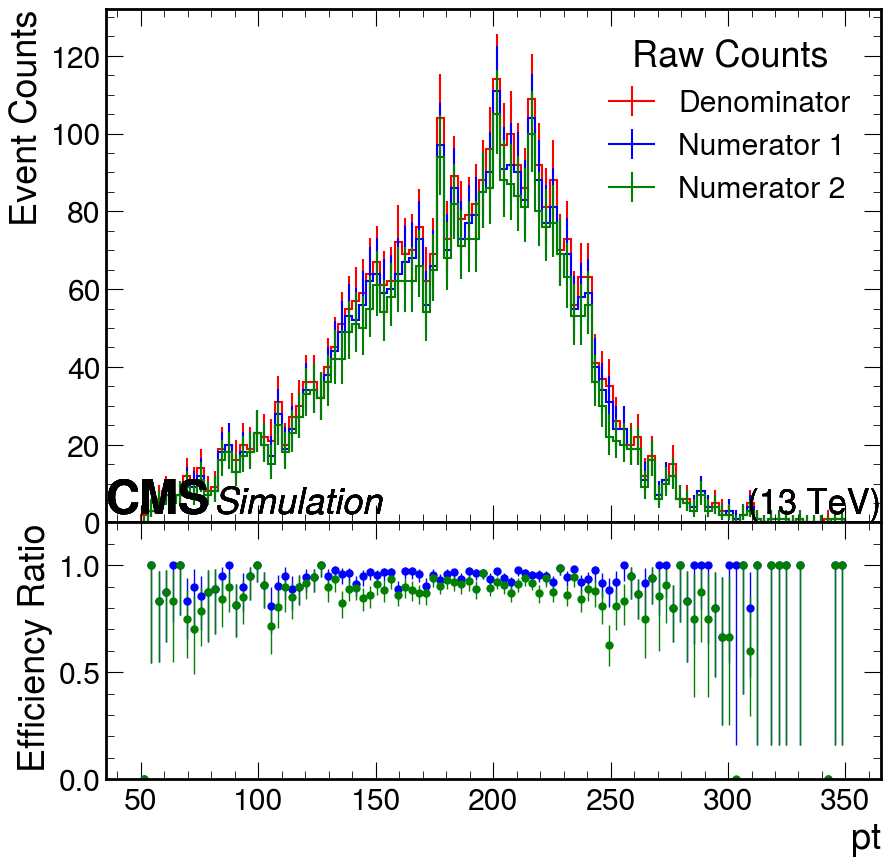

In [73]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 50, 350, name="pt")
num1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den = hist.Hist(pt_axis)

R2Lead_Muon_pt_final_num1 = ak.drop_none(R2Lead_Muon_pt_final[R2combined_mask])
R2Lead_Muon_pt_final_num2 = ak.drop_none(R2Lead_Muon_pt_final[R2HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4])
R2Lead_Muon_pt_final_den = ak.drop_none(R2Lead_Muon_pt_final)

#Fill the histograms with the flattened arrays
num1.fill(R2Lead_Muon_pt_final_num1)
num2.fill(R2Lead_Muon_pt_final_num2)
den.fill(R2Lead_Muon_pt_final_den)

# 1. Plot the ratio. This single command plots the numerator/denominator in the top
#    panel and the ratio in the bottom panel (the subplot).
plot_result = plot_double_efficiency_ratio(
    num1,
    num2,
    den,
    error_opts={"marker": "o", "ms": 4}
)

/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:143: RuntimeWarning: invalid value encountered in divide
  eff_values = num_vals/denom_vals
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:148: RuntimeWarning: invalid value encountered in divide
  num_counts = num_vals**2 / num_hist.variances()
/home/cms-jovyan/SIDM/SIDM/sidm/tools/utilities.py:149: RuntimeWarning: invalid value encountered in divide
  denom_counts = denom_vals**2 / denom_hist.variances()


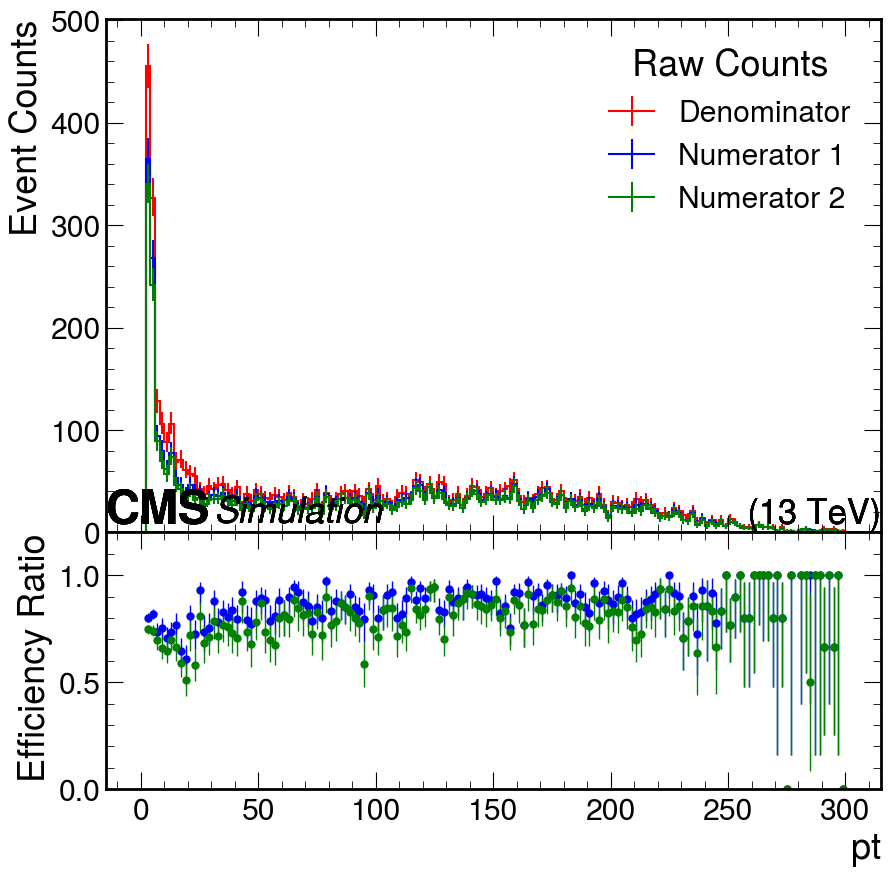

In [62]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(150, 0, 300, name="pt")
num1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den = hist.Hist(pt_axis)

R3Lead_Muon_pt_final_num1 = ak.drop_none(R3Lead_Muon_pt_final[R3combined_mask])
R3Lead_Muon_pt_final_num2 = ak.drop_none(R3Lead_Muon_pt_final[R3HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4])
R3Lead_Muon_pt_final_den = ak.drop_none(R3Lead_Muon_pt_final)

#Fill the histograms with the flattened arrays
num1.fill(R3Lead_Muon_pt_final_num1)
num2.fill(R3Lead_Muon_pt_final_num2)
den.fill(R3Lead_Muon_pt_final_den)

# 1. Plot the ratio. This single command plots the numerator/denominator in the top
#    panel and the ratio in the bottom panel (the subplot).
plot_result = plot_double_efficiency_ratio(
    num1,
    num2,
    den,
    error_opts={"marker": "o", "ms": 4}
)

Plot for Run2 combined mask Second Highest PT

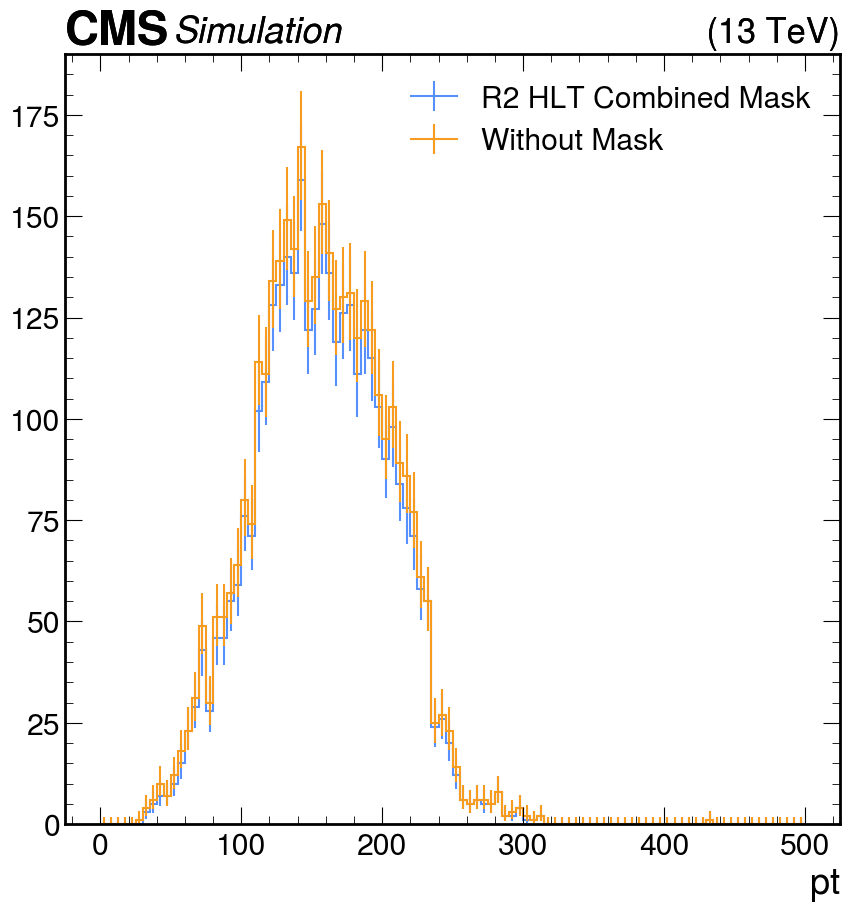

In [34]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(R2second_highest_pt[R2combined_mask])
denominator.fill(R2second_highest_pt)

#Plot both on the same figure
utilities.plot(numerator, label = "R2 HLT Combined Mask")
utilities.plot(denominator, label ="Without Mask")
plt.legend(loc = 'upper right')

Plot for Run3 combined mask Second Highest PT

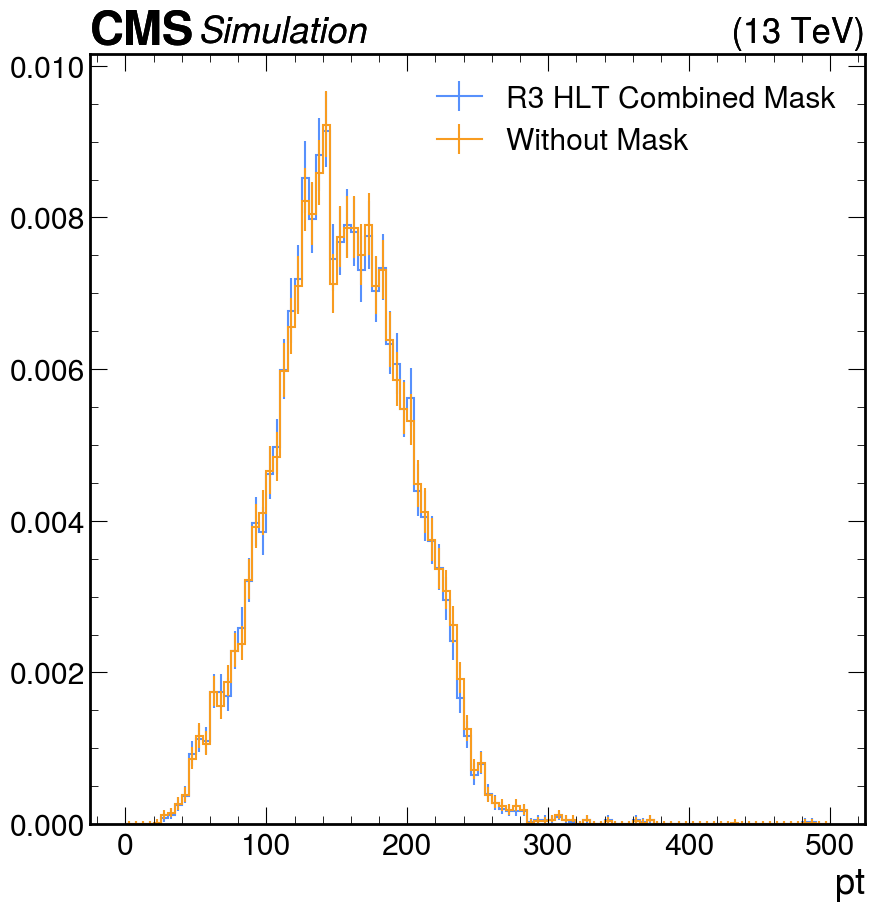

In [35]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 500, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(R3second_highest_pt[R3combined_mask])
denominator.fill(R3second_highest_pt)

#Plot both on the same figure
utilities.plot(numerator, label = "R3 HLT Combined Mask", density=True)
utilities.plot(denominator, label ="Without Mask", density=True)
plt.legend(loc = 'upper right')

Plot comparing efficiencies for Run2 and Run3 combined Mask vs Second highest Muon

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


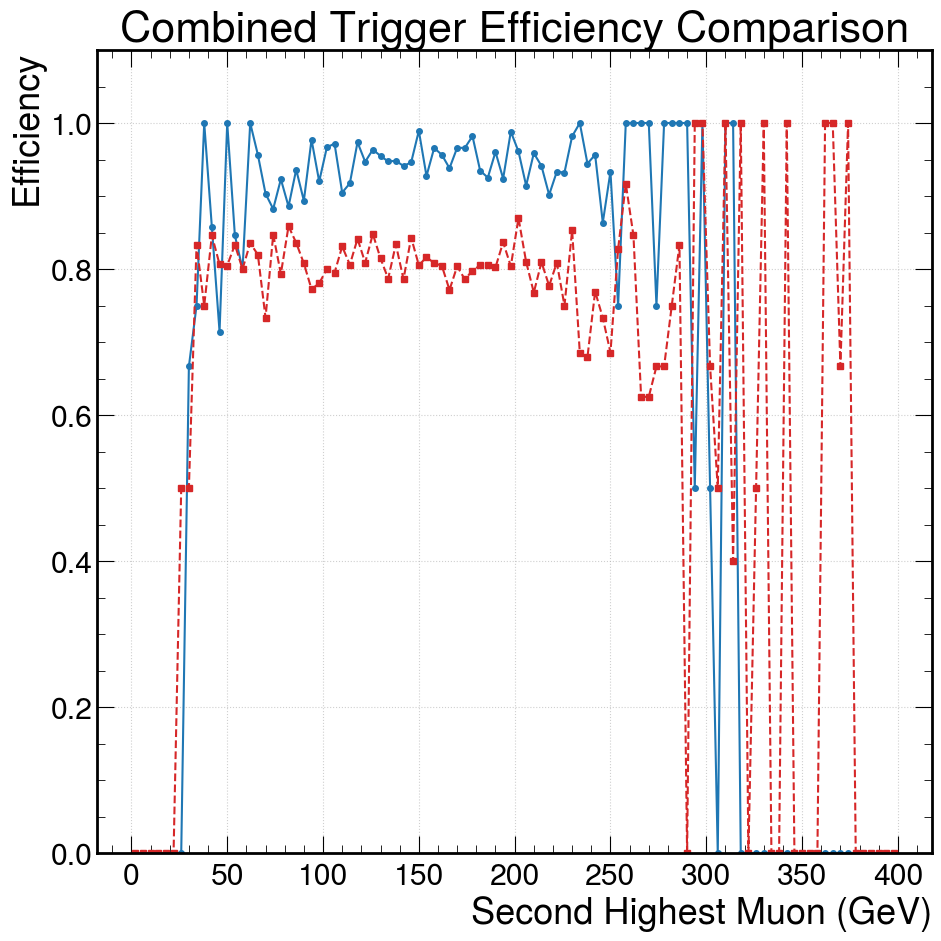

In [36]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(R2second_highest_pt[R2combined_mask])
num2.fill(R3second_highest_pt[R3combined_mask])
den1.fill(R2second_highest_pt)
den2.fill(R3second_highest_pt)

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2 Combined Efficiency",
    label2="R3 Combined Efficiency",
    title="Combined Trigger Efficiency Comparison",
    x_label="Second Highest Muon (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

Plot comparing efficiencies for Run2 and Run3 Single Mask

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


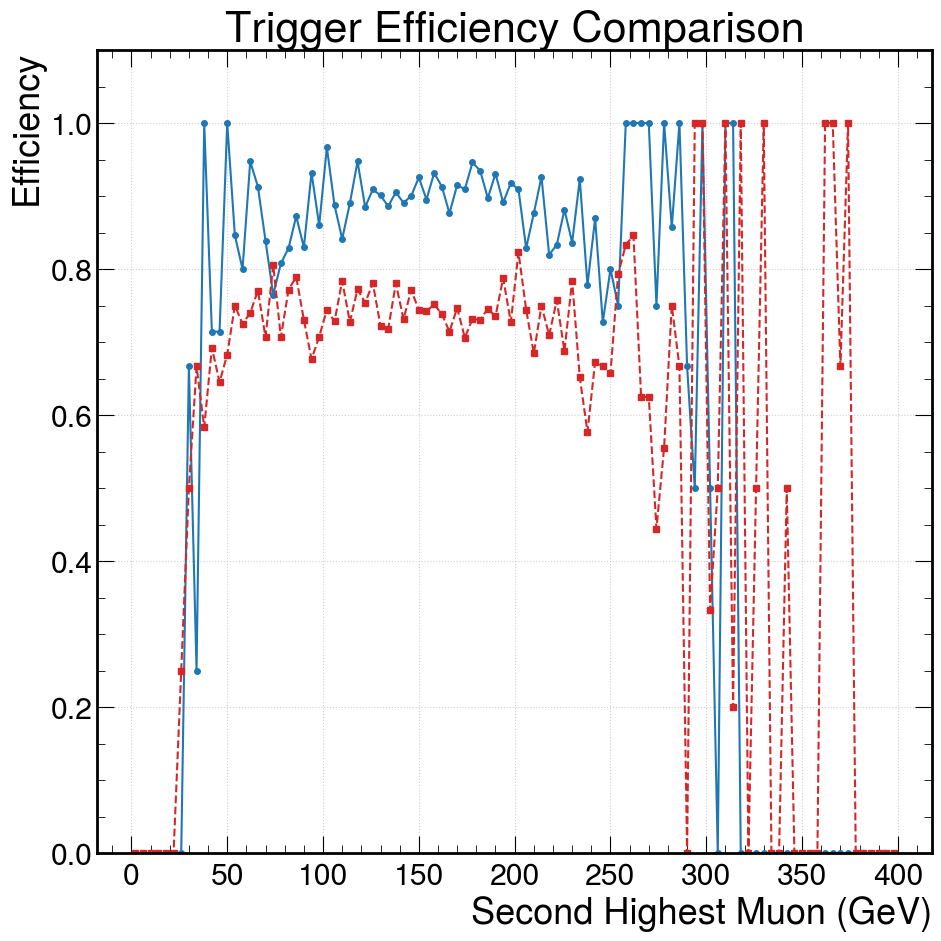

In [37]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(R2second_highest_pt[R2HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4])
num2.fill(R3second_highest_pt[R3HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4])
den1.fill(R2second_highest_pt)
den2.fill(R3second_highest_pt)

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Trigger Efficiency Comparison",
    x_label="Second Highest Muon (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


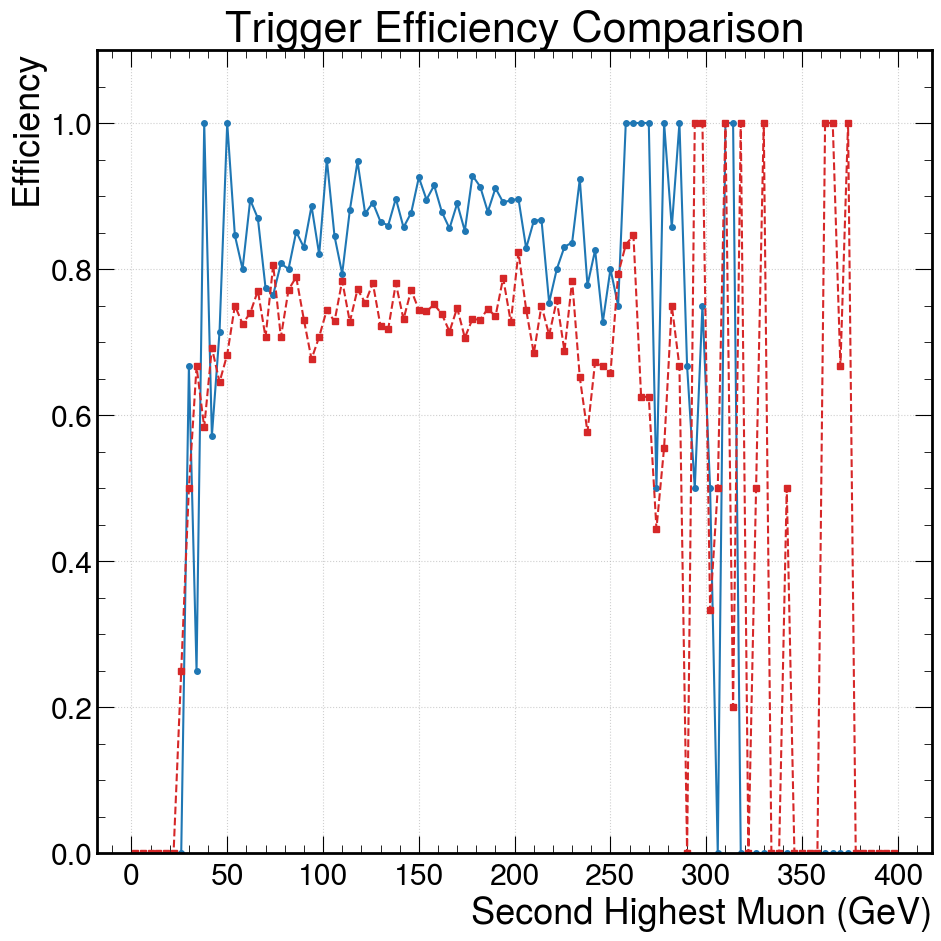

In [38]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(R2second_highest_pt[R2HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4])
num2.fill(R3second_highest_pt[R3HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4])
den1.fill(R2second_highest_pt)
den2.fill(R3second_highest_pt)

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Trigger Efficiency Comparison",
    x_label="Second Highest Muon (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: divide by zero encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


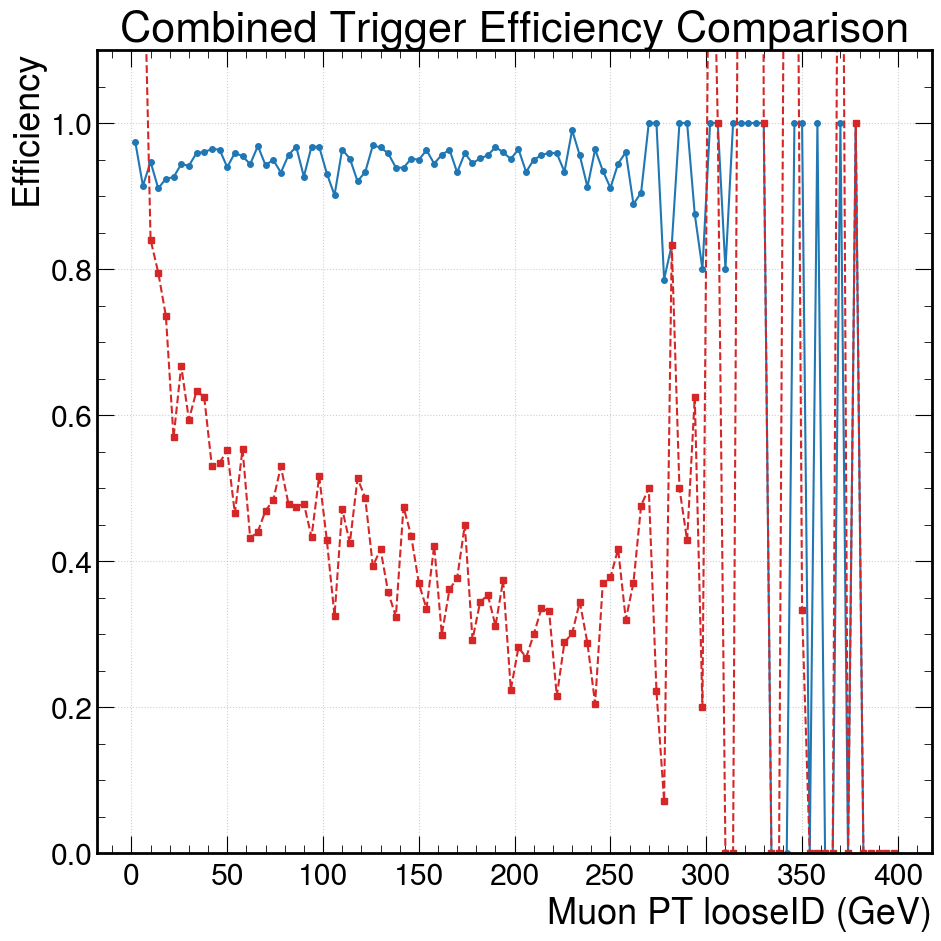

In [39]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(ak.flatten(R2Muon_pt_lID[R2combined_mask]))
num2.fill(ak.flatten(R3Muon_pt_lID[R3combined_mask]))
den1.fill(ak.flatten(R2Muon_pt_lID))
den2.fill(ak.flatten(R2Muon_pt_lID))

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Combined Trigger Efficiency Comparison",
    x_label="Muon PT looseID (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: divide by zero encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


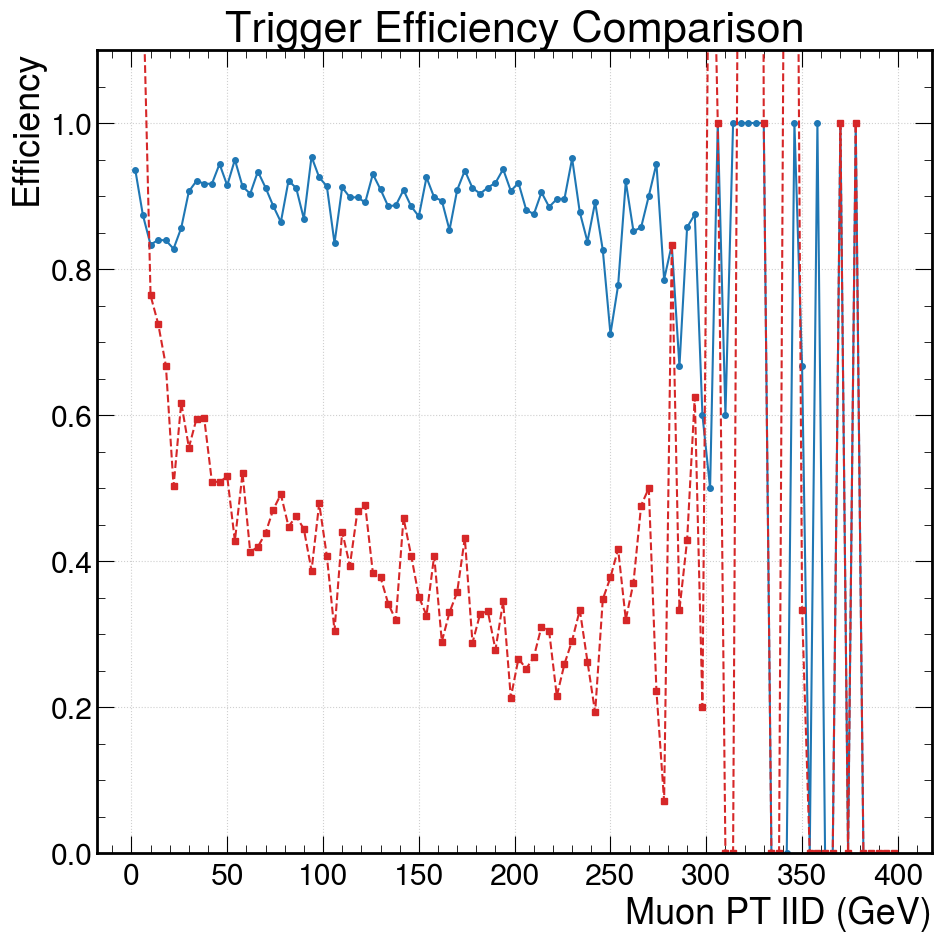

In [40]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(ak.flatten(R2Muon_pt_lID[R2HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))
num2.fill(ak.flatten(R3Muon_pt_lID[R3HLT_DoubleL2Mu25NoVtx_2Cha_Eta2p4]))
den1.fill(ak.flatten(R2Muon_pt_lID))
den2.fill(ak.flatten(R2Muon_pt_lID))

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Trigger Efficiency Comparison",
    x_label="Muon PT lID (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: divide by zero encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


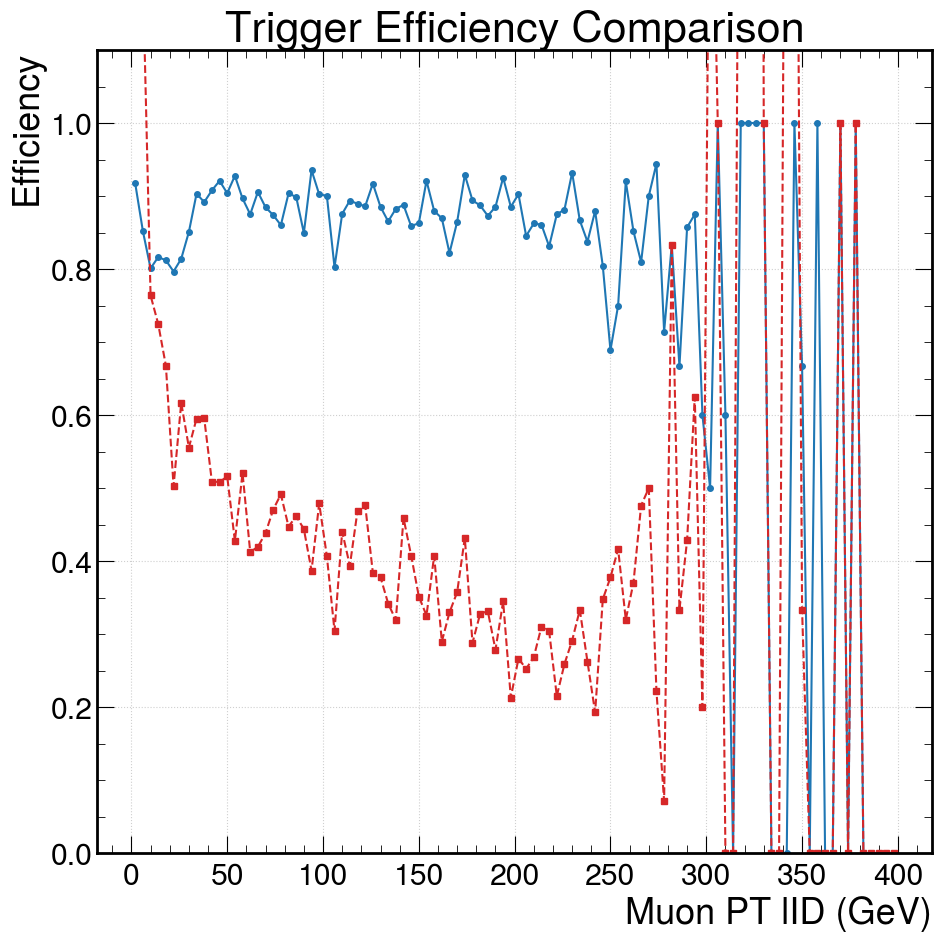

In [41]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
num1.fill(ak.flatten(R2Muon_pt_lID[R2HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4]))
num2.fill(ak.flatten(R3Muon_pt_lID[R3HLT_DoubleL2Mu30NoVtx_2Cha_Eta2p4]))
den1.fill(ak.flatten(R2Muon_pt_lID))
den2.fill(ak.flatten(R2Muon_pt_lID))

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Trigger Efficiency Comparison",
    x_label="Muon PT lID (GeV)",
    error_opts={"marker": "o", "ms": 4}
)

## Run 2 vs. Run 3 Trigger Comparison

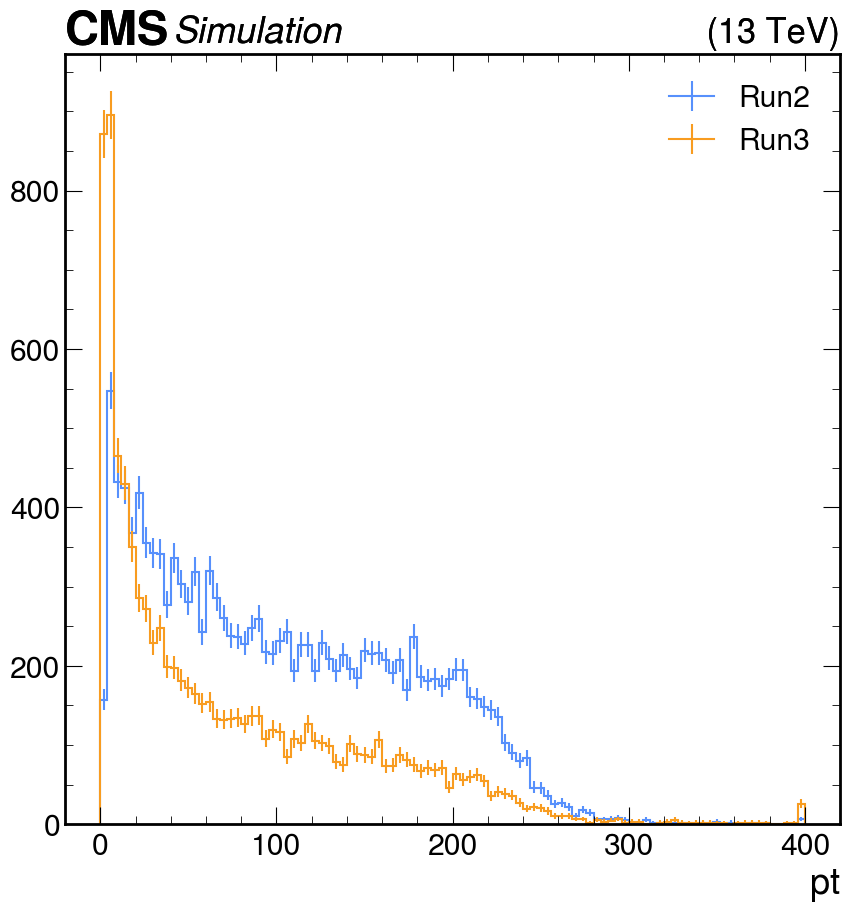

In [69]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
numerator = hist.Hist(pt_axis)
denominator = hist.Hist(pt_axis)

#Fill the histograms with the flattened arrays
numerator.fill(ak.flatten(R2Muon_pt_lID))
denominator.fill(ak.flatten(R3Muon_pt_lID))

#Plot both on the same figure
utilities.plot(numerator, label = "Run2")
utilities.plot(denominator, label ="Run3")
plt.legend(loc = 'upper right')

/tmp/ipykernel_234/1147677802.py:27: RuntimeWarning: invalid value encountered in divide
  eff1 = np.where(den_counts_1 != 0, np.divide(num_counts_1, den_counts_1), 0)
/tmp/ipykernel_234/1147677802.py:30: RuntimeWarning: invalid value encountered in divide
  eff2 = np.where(den_counts_2 != 0, np.divide(num_counts_2, den_counts_2), 0)


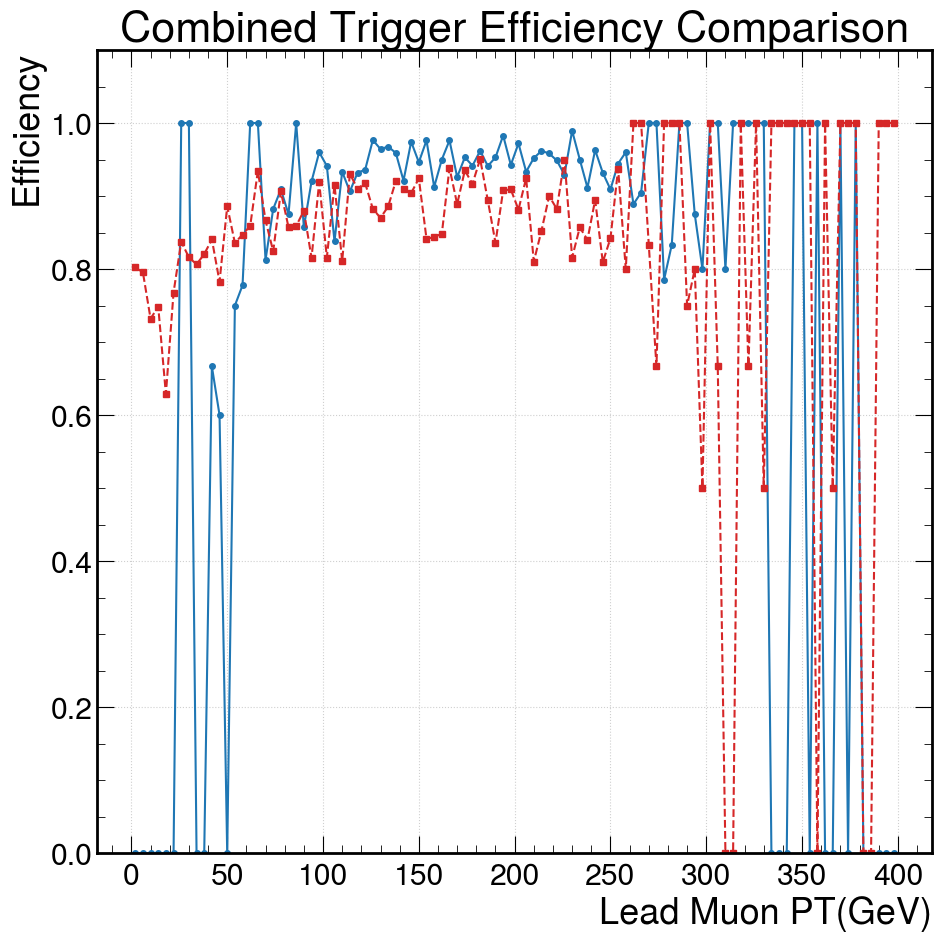

In [70]:
#Define the histograms and the axis
pt_axis = hist.axis.Regular(100, 0, 400, name="pt")
num1 = hist.Hist(pt_axis)
den1 = hist.Hist(pt_axis)
num2 = hist.Hist(pt_axis)
den2 = hist.Hist(pt_axis)

# Set up data arrays
R2Lead_Muon_pt_final_num1 = ak.drop_none(R2Lead_Muon_pt_final[R2combined_mask])
R3Lead_Muon_pt_final_num2 = ak.drop_none(R3Lead_Muon_pt_final[R3combined_mask])
R2Lead_Muon_pt_final_den1 = ak.drop_none(R2Lead_Muon_pt_final)
R3Lead_Muon_pt_final_den2 = ak.drop_none(R3Lead_Muon_pt_final)

#Fill the histograms with the flattened arrays
num1.fill(R2Lead_Muon_pt_final_num1)
num2.fill(R3Lead_Muon_pt_final_num2)
den1.fill(R2Lead_Muon_pt_final_den1)
den2.fill(R3Lead_Muon_pt_final_den2)

#Plot
plot_result = plot_efficiency_only(
    num1,
    num2,
    den1,
    den2,
    label1="R2",
    label2="R3",
    title="Combined Trigger Efficiency Comparison",
    x_label="Lead Muon PT(GeV)",
    error_opts={"marker": "o", "ms": 4}
)